# Backtest Results Analysis

This notebook analyzes the results from your Kalshi backtesting grid search.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load the backtest results
df = pd.read_csv('backtest_results_log.csv')
print(f"Loaded {len(df)} backtest results")
df.head()

Loaded 81 backtest results


,run_timestamp,market_ticker,strategy,start_date,end_date,final_pnl,return_pct,win_rate,sharpe_ratio,max_drawdown,...,pnl_middle,pnl_last_hour,sma_window,fixed_spread,gamma,sigma,k,min_spread,inventory_skew_factor,max_position
0,2025-07-30 01:56:28,KXHIGHLAX-25JUL27-B71.5,simple,2025-07-26 10:00,2025-07-26 23:59,-1.25,-0.125,0.000000,-0.858139,2.35,...,-1.13,-0.12,2,0.02,NaN,NaN,NaN,NaN,0.000,10
1,2025-07-30 01:56:29,KXHIGHLAX-25JUL27-B71.5,simple,2025-07-26 10:00,2025-07-26 23:59,-1.34,-0.134,0.000000,0.000000,2.31,...,-1.34,0.00,3,0.02,NaN,NaN,NaN,NaN,0.000,10
2,2025-07-30 01:56:29,KXHIGHLAX-25JUL27-B71.5,simple,2025-07-26 10:00,2025-07-26 23:59,-0.51,-0.051,0.000000,-0.632237,2.31,...,-0.48,-0.03,5,0.02,NaN,NaN,NaN,NaN,0.000,10
3,2025-07-30 01:56:30,KXHIGHLAX-25JUL27-B71.5,simple,2025-07-26 10:00,2025-07-26 23:59,-1.32,-0.132,0.000000,-1.187696,3.68,...,-1.20,-0.12,2,0.02,NaN,NaN,NaN,NaN,0.001,10
4,2025-07-30 01:56:31,KXHIGHLAX-25JUL27-B71.5,simple,2025-07-26 10:00,2025-07-26 23:59,-0.92,-0.092,0.333333,-0.793841,3.82,...,-0.92,0.00,3,0.02,NaN,NaN,NaN,NaN,0.001,10


In [11]:
# Basic statistics
print("=== PERFORMANCE SUMMARY ===")
print(f"Average Return: {df['return_pct'].mean():.2f}%")
print(f"Best Return: {df['return_pct'].max():.2f}%")
print(f"Worst Return: {df['return_pct'].min():.2f}%")
print(f"Average Win Rate: {df['win_rate'].mean():.2%}")
print(f"Average Sharpe Ratio: {df['sharpe_ratio'].mean():.2f}")
print(f"Average Fills: {df['total_fills'].mean():.2f}")
print(f"Average Sharpe Ratio: {df['sharpe_ratio'].mean():.2f}")
print(f"Average Round Trip Trade: {df['round_trip_trades'].mean():.2f}")
print(f"Average Total Market Trades: {df['total_market_trades'].mean():.2f}")


# Show top 5 performing parameter combinations
print("\n=== TOP 5 PARAMETER COMBINATIONS ===")
top_performers = df.nlargest(5, 'return_pct')
for idx, row in top_performers.iterrows():
    print(f"Return: {row['return_pct']:.2f}% | Win Rate: {row['win_rate']:.2%} | Sharpe: {row['sharpe_ratio']:.2f} | Position: {row['final_position']:.2f} | PnL: {row['final_pnl']:.2f}")
    print(f"  Params: fixed_spread={row['fixed_spread']}, inventory_skew_factor={row['inventory_skew_factor']}, sma_window={row['sma_window']}")
    print(f"  Intra-Day PnL -> First Hour: ${row['pnl_first_hour']:.2f}, Middle: ${row['pnl_middle']:.2f}, Last Hour: ${row['pnl_last_hour']:.2f}")
    print()

=== PERFORMANCE SUMMARY ===
Average Return: -0.32%
Best Return: -0.03%
Worst Return: -0.72%
Average Win Rate: 0.82%
Average Sharpe Ratio: -1.53
Average Fills: 17.51
Average Sharpe Ratio: -1.53
Average Round Trip Trade: 1.65
Average Total Market Trades: 260.33

=== TOP 5 PARAMETER COMBINATIONS ===
Return: -0.03% | Win Rate: 0.00% | Sharpe: -0.87 | Position: -1.00 | PnL: -0.32
  Params: fixed_spread=0.02, inventory_skew_factor=0.001, sma_window=5
  Intra-Day PnL -> First Hour: $0.00, Middle: $-0.29, Last Hour: $-0.03

Return: -0.04% | Win Rate: 0.00% | Sharpe: 0.00 | Position: -2.00 | PnL: -0.38
  Params: fixed_spread=0.04, inventory_skew_factor=0.01, sma_window=5
  Intra-Day PnL -> First Hour: $0.00, Middle: $-0.32, Last Hour: $-0.06

Return: -0.04% | Win Rate: 33.33% | Sharpe: -0.46 | Position: -3.00 | PnL: -0.39
  Params: fixed_spread=0.02, inventory_skew_factor=0.01, sma_window=3
  Intra-Day PnL -> First Hour: $0.00, Middle: $-0.30, Last Hour: $-0.09

Return: -0.05% | Win Rate: 0.00%

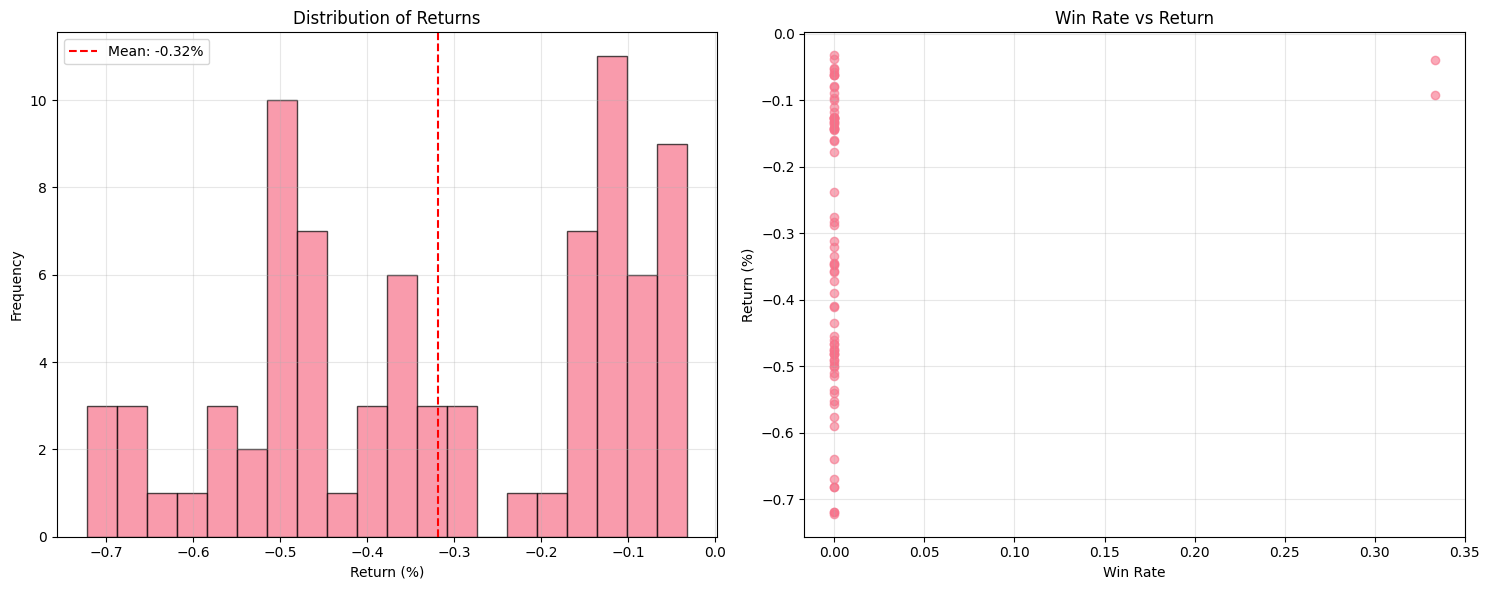

In [3]:
# Visualize return distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Return distribution
ax1.hist(df['return_pct'], bins=20, alpha=0.7, edgecolor='black')
ax1.axvline(df['return_pct'].mean(), color='red', linestyle='--', label=f'Mean: {df["return_pct"].mean():.2f}%')
ax1.set_xlabel('Return (%)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Returns')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Win rate vs Return scatter
ax2.scatter(df['win_rate'], df['return_pct'], alpha=0.6)
ax2.set_xlabel('Win Rate')
ax2.set_ylabel('Return (%)')
ax2.set_title('Win Rate vs Return')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

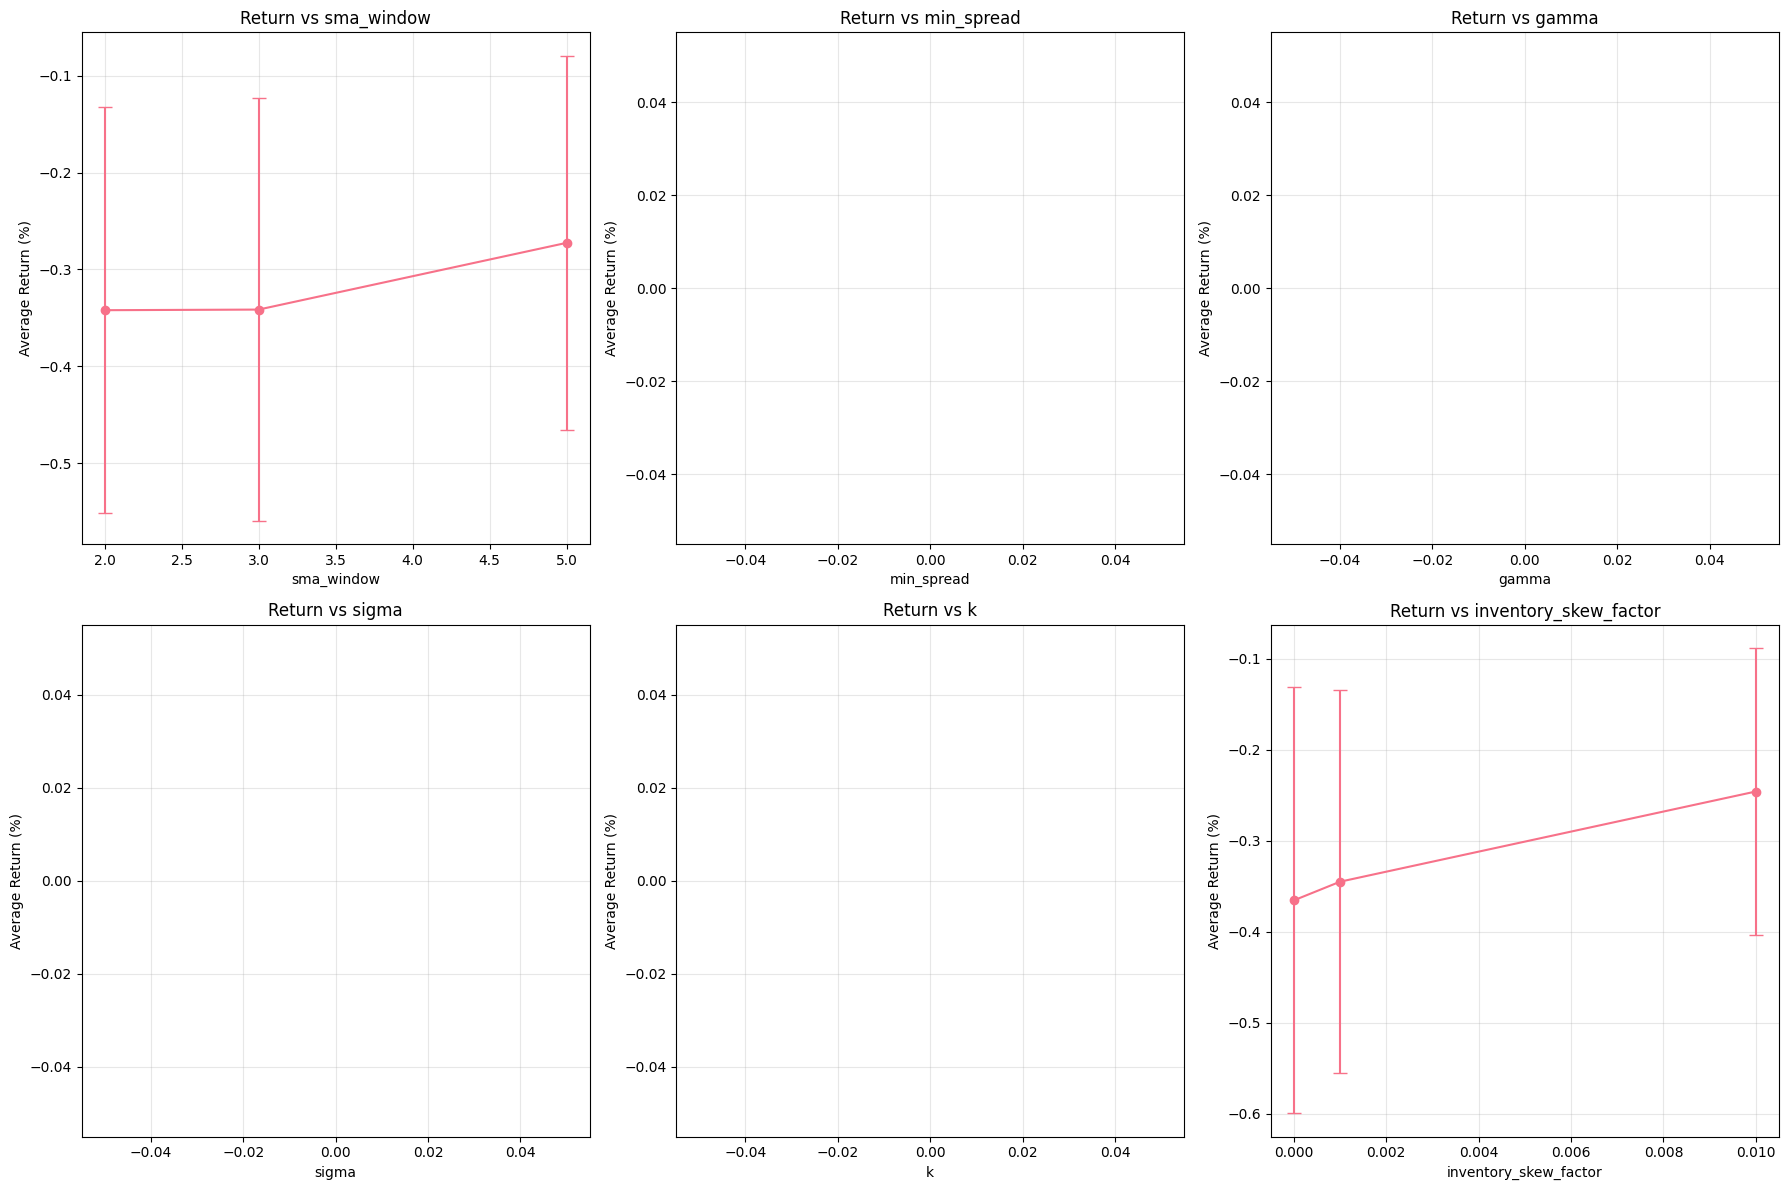

In [4]:
# Parameter sensitivity analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

params = ['sma_window', 'min_spread', 'gamma', 'sigma', 'k', 'inventory_skew_factor']

for i, param in enumerate(params):
    if param in df.columns:
        param_grouped = df.groupby(param)['return_pct'].agg(['mean', 'std']).reset_index()
        
        axes[i].errorbar(param_grouped[param], param_grouped['mean'], 
                        yerr=param_grouped['std'], marker='o', capsize=5)
        axes[i].set_xlabel(param)
        axes[i].set_ylabel('Average Return (%)')
        axes[i].set_title(f'Return vs {param}')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

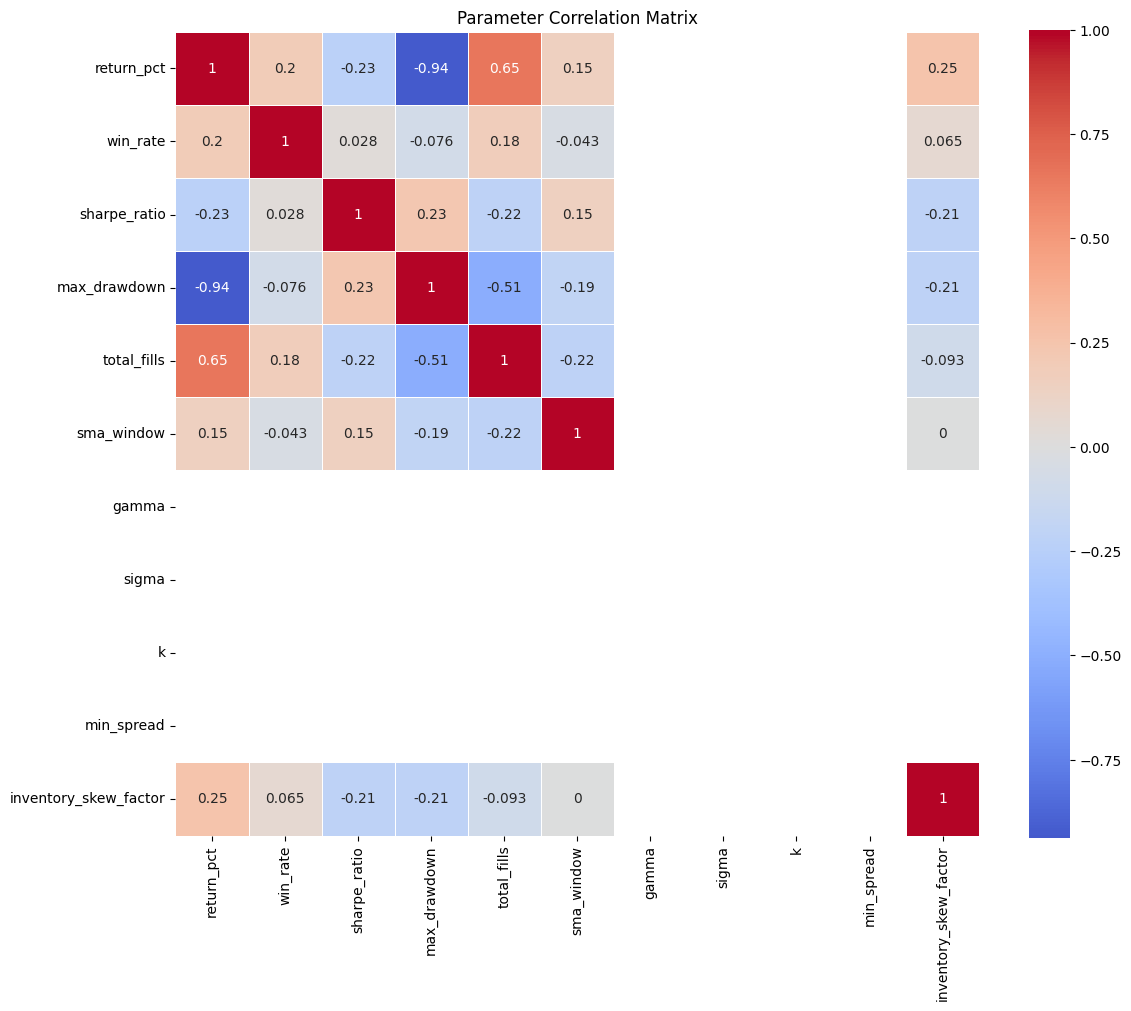

In [5]:
# Correlation heatmap
numeric_cols = ['return_pct', 'win_rate', 'sharpe_ratio', 'max_drawdown', 'total_fills',
                'sma_window', 'gamma', 'sigma', 'k', 'min_spread', 'inventory_skew_factor']
correlation_data = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Parameter Correlation Matrix')
plt.tight_layout()
plt.show()

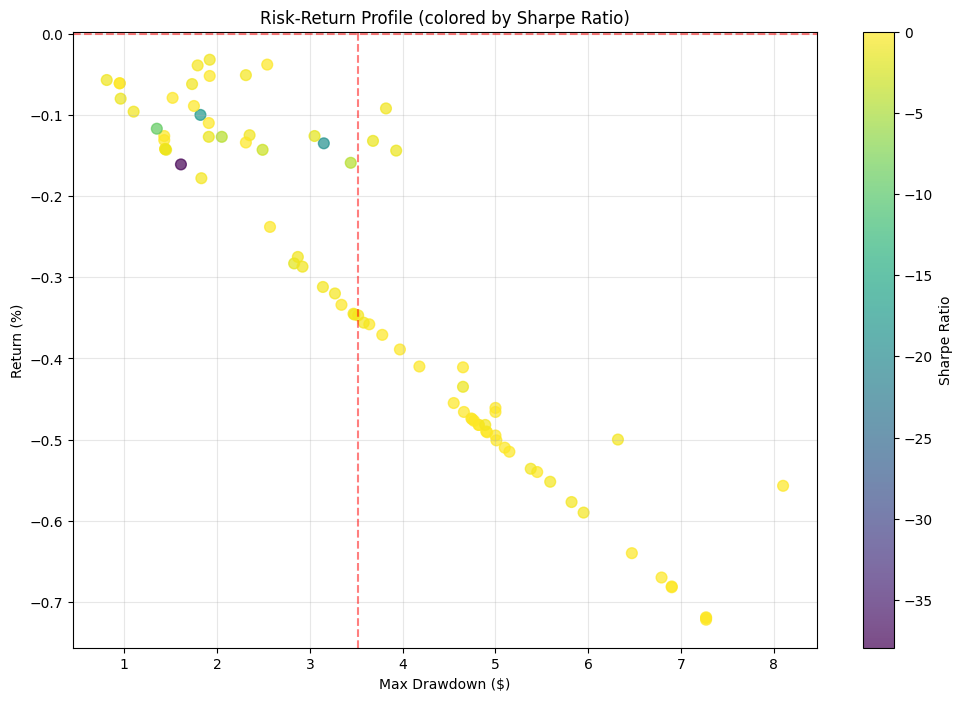

In [6]:
# Risk-Return analysis
plt.figure(figsize=(12, 8))

# Create scatter plot colored by Sharpe ratio
scatter = plt.scatter(df['max_drawdown'], df['return_pct'], 
                     c=df['sharpe_ratio'], cmap='viridis', alpha=0.7, s=60)

plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Max Drawdown ($)')
plt.ylabel('Return (%)')
plt.title('Risk-Return Profile (colored by Sharpe Ratio)')
plt.grid(True, alpha=0.3)

# Add quadrant lines
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=df['max_drawdown'].median(), color='red', linestyle='--', alpha=0.5)

plt.show()

=== PERFORMANCE BY MARKET ===
                        return_pct              win_rate sharpe_ratio  \
                              mean    std count     mean         mean   
market_ticker                                                           
KXHIGHAUS-25JUL27-B96.5     -0.451  0.191    27    0.000       -0.428   
KXHIGHDEN-25JUL27-B97.5     -0.374  0.152    27    0.000       -1.991   
KXHIGHLAX-25JUL27-B71.5     -0.131  0.121    27    0.025       -2.166   

                        round_trip_trades  
                                     mean  
market_ticker                              
KXHIGHAUS-25JUL27-B96.5             1.741  
KXHIGHDEN-25JUL27-B97.5             1.370  
KXHIGHLAX-25JUL27-B71.5             1.852  


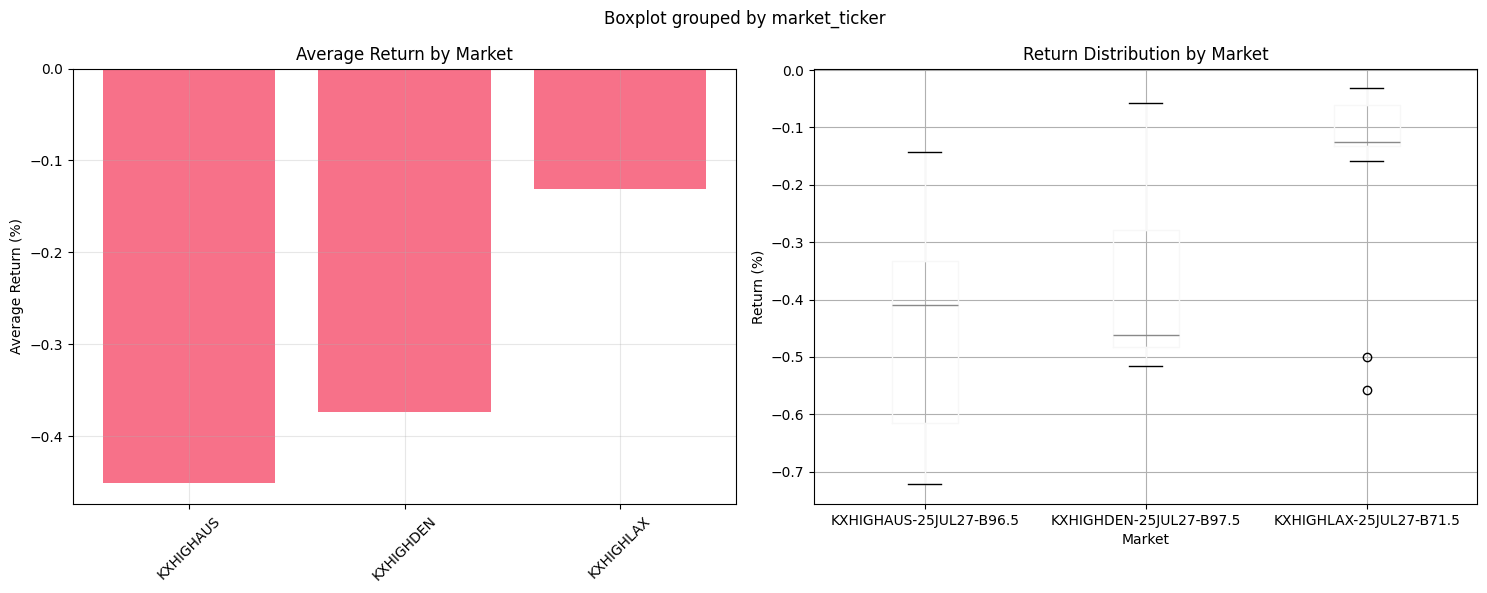

In [7]:
# Market-specific analysis
if 'market_ticker' in df.columns:
    market_performance = df.groupby('market_ticker').agg({
        'return_pct': ['mean', 'std', 'count'],
        'win_rate': 'mean',
        'sharpe_ratio': 'mean',
        'round_trip_trades': 'mean'  # Add this line
    }).round(3)
    
    print("=== PERFORMANCE BY MARKET ===")
    print(market_performance)
    
    # Plot market performance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    market_means = df.groupby('market_ticker')['return_pct'].mean()
    ax1.bar(range(len(market_means)), market_means.values)
    ax1.set_xticks(range(len(market_means)))
    ax1.set_xticklabels([ticker.split('-')[0] for ticker in market_means.index], rotation=45)
    ax1.set_ylabel('Average Return (%)')
    ax1.set_title('Average Return by Market')
    ax1.grid(True, alpha=0.3)
    
    # Box plot of returns by market
    df.boxplot(column='return_pct', by='market_ticker', ax=ax2)
    ax2.set_xlabel('Market')
    ax2.set_ylabel('Return (%)')
    ax2.set_title('Return Distribution by Market')
    
    plt.tight_layout()
    plt.show()

In [12]:
# --- HIGHEST FILLS ANALYSIS ---
# This shows which parameter sets are generating the most raw trading activity.

print("=== TOP 5 STRATEGIES BY TOTAL FILLS ===")
top_by_fills = df.nlargest(5, 'total_fills')

for idx, row in top_by_fills.iterrows():
    print(f"Total Fills: {row['total_fills']} | Return: {row['return_pct']:.2f}% | Sharpe: {row['sharpe_ratio']:.2f} | Round Trips: {row['round_trip_trades']}, Total Trades: {row['total_market_trades']}")
    print(f"  Params: sma_window={row['sma_window']}, min_spread={row['min_spread']}, gamma={row['gamma']}, sigma={row['sigma']}, k={row['k']}, inventory_skew_factor={row['inventory_skew_factor']}")
    print()

=== TOP 5 STRATEGIES BY TOTAL FILLS ===
Total Fills: 40 | Return: -0.13% | Sharpe: -1.19 | Round Trips: 4, Total Trades: 294
  Params: sma_window=2, min_spread=nan, gamma=nan, sigma=nan, k=nan, inventory_skew_factor=0.001

Total Fills: 36 | Return: -0.13% | Sharpe: -4.28 | Round Trips: 2, Total Trades: 294
  Params: sma_window=2, min_spread=nan, gamma=nan, sigma=nan, k=nan, inventory_skew_factor=0.001

Total Fills: 35 | Return: -0.10% | Sharpe: -17.68 | Round Trips: 2, Total Trades: 294
  Params: sma_window=2, min_spread=nan, gamma=nan, sigma=nan, k=nan, inventory_skew_factor=0.0

Total Fills: 33 | Return: -0.12% | Sharpe: -0.86 | Round Trips: 2, Total Trades: 294
  Params: sma_window=2, min_spread=nan, gamma=nan, sigma=nan, k=nan, inventory_skew_factor=0.0

Total Fills: 30 | Return: -0.09% | Sharpe: -0.79 | Round Trips: 3, Total Trades: 294
  Params: sma_window=3, min_spread=nan, gamma=nan, sigma=nan, k=nan, inventory_skew_factor=0.001

